In [2]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime
from pathlib import Path

In [3]:
# Find nearest index
def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

In [15]:
#Set working Directory for atm chem
result_dir_atm = Path('/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.001/atm/proc/tseries/month_1')

#Read in wet dep all files together
atm_bc_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.bc_*SFWET.200101-202212.nc"
nc_load_bc = xr.open_mfdataset(str(result_dir_atm/atm_bc_files_to_open),combine='nested')
#nc_load_bc

In [16]:
#Set working directory for lnd model
result_dir_lnd = Path('/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.001/lnd/proc/tseries/month_1')

#Read in all files together
lnd_bc_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.clm2.h0.BCDEP.200101-202110.nc"
nc_load_bc_lnd = xr.open_mfdataset(str(result_dir_lnd/lnd_bc_files_to_open),combine='nested')
#nc_load_bc_lnd

In [17]:
##Read in dry dep all files together
dry_bc_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.bc_*DDF.200101-202212.nc"
nc_load_bcdry = xr.open_mfdataset(str(result_dir_atm/dry_bc_files_to_open),combine='nested')
#nc_load_bcdry

In [23]:
#Subset the bc dep variables from the datasets
bc_atm = nc_load_bc[['bc_c1SFWET','bc_c4SFWET' , 'bc_a1SFWET' ,'bc_a4SFWET']]
bc_atm_dry = nc_load_bcdry[['bc_c1DDF','bc_c4DDF' , 'bc_a1DDF' ,'bc_a4DDF']]
bc_lnd = nc_load_bc_lnd[['BCDEP']]

#Sum the bc vars in atm model
bc_atm['BC_sum_wet'] = bc_atm['bc_c1SFWET'] + bc_atm['bc_c4SFWET'] + bc_atm['bc_a1SFWET'] + bc_atm['bc_a4SFWET']
bc_atm['BC_sum_a_wet'] = bc_atm['bc_a1SFWET'] + bc_atm['bc_a4SFWET']
bc_atm_dry['BC_sum_dry'] = bc_atm_dry['bc_c1DDF'] + bc_atm_dry['bc_c4DDF'] + bc_atm_dry['bc_a1DDF'] + bc_atm_dry['bc_a4DDF']
bc_atm['BC_sum_wetdry'] = bc_atm['BC_sum_wet'] + (bc_atm_dry['BC_sum_dry']*-1)

In [25]:
#Select and extract the location
name_select = "Boulder"
lat_select = 40.0150
lon_select = 360-105.2705 # model longitude is from 0 to 360
conversions = 2.628e6*10000 #(seconds to months and m2 to hectare)

#For the atm model select site
lat_atm = bc_atm['lat']
lon_atm = bc_atm['lon']
var_sel_atm = bc_atm[['bc_c1SFWET','bc_c4SFWET' , 'bc_a1SFWET' ,'bc_a4SFWET', 'BC_sum_wet', 'BC_sum_wetdry']]

# CAM-chem writes the month average at midnight - i.e. the start of the next month.
# Reconfigure the time variable
time_atm = bc_atm['time']
time2_atm = pd.to_datetime(time_atm.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)
print("file time: ", time_atm[0].values, "---> converted time: ", time2_atm[0])

lat_i_atm = find_index(lat_atm.values, lat_select)
lon_i_atm = find_index(lon_atm.values, lon_select)

print(name_select, " latitude: ", lat_select, "---> nearest: ", lat_atm[lat_i_atm].values)
print(name_select, " longitude: ", lon_select, "---> nearest: ", lon_atm[lon_i_atm].values)

var_srf_atm = var_sel_atm.isel(lat=lat_i_atm,lon=lon_i_atm)*-1*conversions #Convert to positive values, negative because its a flux TO surface

file time:  2001-02-01T00:00:00.000000000 ---> converted time:  2001-01-15 00:00:00
Boulder  latitude:  40.015 ---> nearest:  40.0523560209424
Boulder  longitude:  254.7295 ---> nearest:  255.0


In [26]:
#For the lnd model select site
lat_lnd = bc_lnd['lat']
lon_lnd = bc_lnd['lon']
var_sel_lnd = bc_lnd[['BCDEP']]

# CAM-chem writes the month average at midnight - i.e. the start of the next month.
# Reconfigure the time variable
time_lnd = bc_lnd['time']
time2_lnd = pd.to_datetime(time_lnd.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)
print("file time: ", time_lnd[0].values, "---> converted time: ", time2_lnd[0])

lat_i_lnd = find_index(lat_lnd.values, lat_select)
lon_i_lnd = find_index(lon_lnd.values, lon_select)

print(name_select, " latitude: ", lat_select, "---> nearest: ", lat_lnd[lat_i_lnd].values)
print(name_select, " longitude: ", lon_select, "---> nearest: ", lon_lnd[lon_i_lnd].values)

var_srf_lnd = var_sel_lnd.isel(lat=lat_i_lnd,lon=lon_i_lnd)*conversions #don't need to convert to positive values here because already considered flux TO

file time:  2001-02-01T00:00:00.000000000 ---> converted time:  2001-01-15 00:00:00
Boulder  latitude:  40.015 ---> nearest:  40.052357
Boulder  longitude:  254.7295 ---> nearest:  255.0


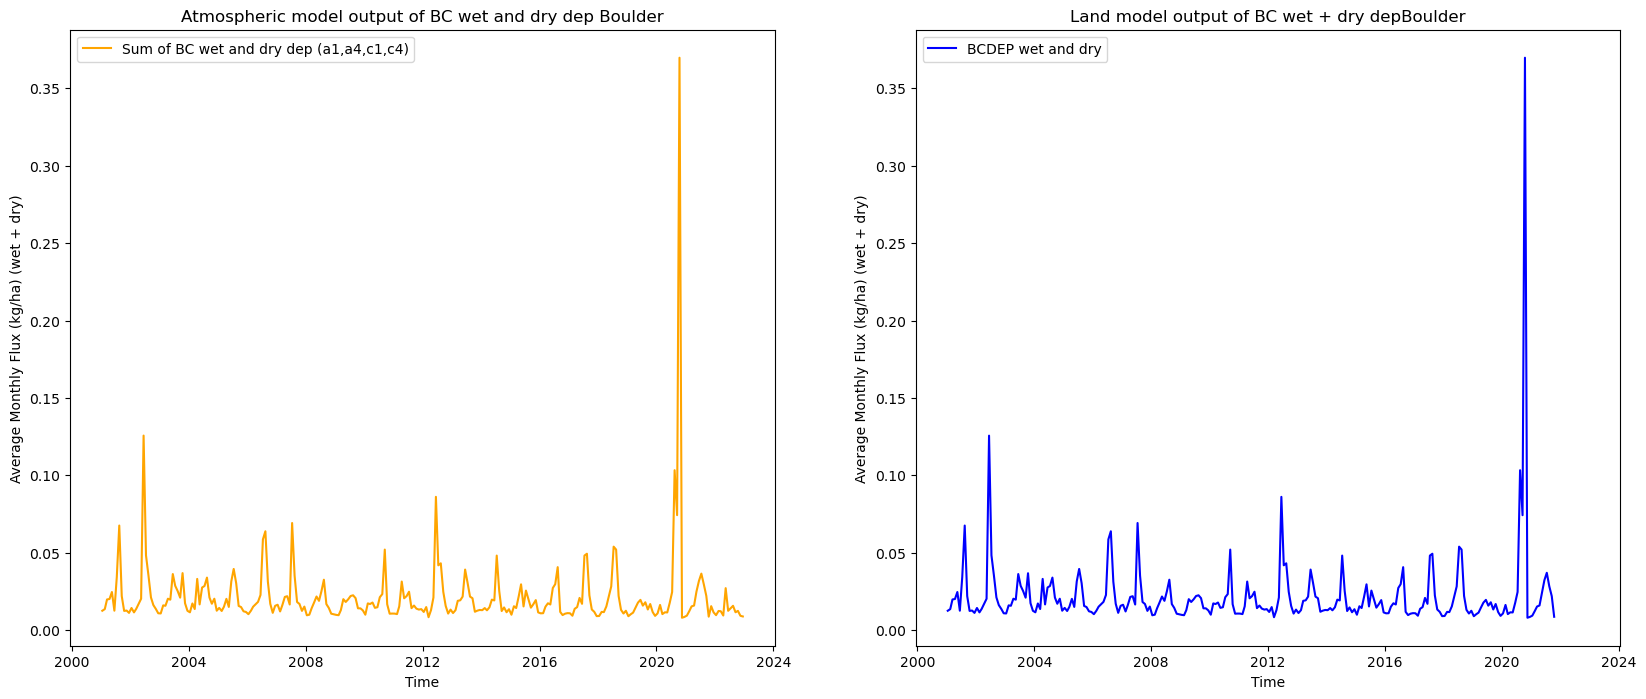

In [33]:
#plot it
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=False, sharex = True)

#Atm plot
ax1.plot(time2_atm, var_srf_atm['BC_sum_wetdry'], label = 'Sum of BC wet and dry dep (a1,a4,c1,c4)', color = 'orange')
ax1.set_title('Atmospheric model output of BC wet and dry dep ' + name_select)
ax1.set_xlabel('Time')
ax1.set_ylabel('Average Monthly Flux (kg/ha) (wet + dry)')
ax1.legend()

# lnd plot
ax2.plot(time2_lnd, var_srf_lnd['BCDEP'], label = 'BCDEP wet and dry', color = 'blue')
ax2.set_title('Land model output of BC wet + dry dep ' + name_select)
ax2.set_xlabel('Time')
ax2.set_ylabel('Average Monthly Flux (kg/ha) (wet + dry)')
ax2.legend()
plt.show()